# Pretraining on unlabeled data

## Evaluating generative text models

In [26]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow"]

for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.11.1
numpy version: 2.4.4
tiktoken version: 0.13.0
torch version: 2.6.0+cu124
tensorflow version: 2.21.0


In [4]:
from matplotlib import pyplot as plt
import numpy as np
import tiktoken
import torch
import torch.nn as nn
import tensorflow
import tqdm
from pt_4_implementing_a_gpt_model.practice import GPTModel, generate_text_simple

In [6]:


GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [29]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [30]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text, allowed_special={"<|endoftext|>"})).unsqueeze(dim=0)

def ids_to_text(ids, tokenizer):
    return tokenizer.decode(ids.squeeze(0).tolist())

In [31]:
start_content = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

In [32]:
ids = text_to_token_ids(start_content, tokenizer)
text = ids_to_text(ids, tokenizer)

print(ids)
print(text)

tensor([[6109, 3626, 6100,  345]])
Every effort moves you


In [33]:
token_ids = generate_text_simple(
        model=model,
        idx=text_to_token_ids(start_content, tokenizer),
        max_new_tokens=6,
        context_size=GPT_CONFIG_124M["context_length"]
    )
print(token_ids)

tensor([[ 6109,  3626,  6100,   345, 13210, 24866, 50133, 38907,  2393, 35436]])


In [34]:
print(ids_to_text(token_ids, tokenizer))

Every effort moves youoj correspondsksh578 filepain


## Calculating the text generation loss: cross-entropy and perplexity

In [35]:
inputs = torch.tensor([[16833, 3626, 6100], # every effort moves
                       [40, 1107, 588]])    # I really like
targets = torch.tensor([[3626, 6100, 345],  # effort moves you
                       [1107, 588, 11311]]) # really like chocolate

with torch.inference_mode():
    model.eval()
    logits = model(inputs)

In [36]:
print(logits.shape)

torch.Size([2, 3, 50257])


In [37]:
probs = torch.softmax(logits, dim=-1)
print(probs.shape)
#print(probs)

torch.Size([2, 3, 50257])


In [38]:
preds = torch.argmax(probs, dim=-1, keepdim=True)
print(preds)

tensor([[[45073],
         [20394],
         [ 1816]],

        [[ 3831],
         [35446],
         [23701]]])


In [39]:
print(f"Targets batch 1: {ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {ids_to_text(preds[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1: gur repeating went


In [40]:
loss_fn = nn.CrossEntropyLoss()

logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

loss = loss_fn(logits_flat, targets_flat)
print(loss)

tensor(10.5956)


## Calculating the training and validation set losses

In [41]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists("the-verdict.txt"):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open("the-verdict.txt", "r", encoding="utf-8") as f:
        text_data = f.read()

In [42]:
total_chars = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print(f"Characters: {total_chars}")
print(f"Tokens: {total_tokens}")

Characters: 20484
Tokens: 5148


In [43]:
from funcs_and_classes import *

train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(1); torch.cuda.manual_seed(1)


train_loader = create_dataloader_v1(
    txt=train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=4
)

val_loader = create_dataloader_v1(
    txt=val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=4
)

In [44]:
def generate_text_test(max_new_tokens, sample_text, model, device):
    model.to(device)
    tokenizer = tiktoken.get_encoding("gpt2")
    ids = tokenizer.encode(sample_text, allowed_special={"<|endoftext|>"})
    ids = torch.tensor(ids).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():

        for _ in range(max_new_tokens):
            logits = model(ids)
            logits = logits[:, -1]
            id_next = torch.argmax(logits, dim=-1, keepdim=True)
            ids = torch.cat((ids, id_next), dim=1)

    ids = ids.squeeze().tolist()
    text = tokenizer.decode(ids)

    return text

def train_model(train_loader,
                model,
                loss_fn,
                optimizer,
                EPOCHS,
                val_loader,
                device,
                sample_text,
                MAX_NEW_TOKENS,
                scheduler):

    train_losses, val_losses, epochs = [], [], []

    for epoch in range(1, EPOCHS + 1):

        train_loss, val_loss = 0, 0

        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            loss = loss_fn(
                logits.view(logits.shape[0] * logits.shape[1], logits.shape[2]),
                y.flatten())
            train_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        with torch.inference_mode():

            for X, y in val_loader:
                X, y = X.to(device), y.to(device)

                logits = model(X)
                loss = loss_fn(
                    logits.view(logits.shape[0] * logits.shape[1], logits.shape[2]),
                    y.flatten())
                val_loss += loss.item()

            val_loss /= len(val_loader)
        val_losses.append(val_loss)
        epochs.append(epoch)

        #scheduler.step()

        print(f"\nEpoch: {epoch} | Train loss: {train_loss} | Val loss: {val_loss}")

        text = generate_text_test(MAX_NEW_TOKENS, sample_text, model, device)
        print(f"Text generation test: \n{text}")

    return model, train_losses, val_losses, epochs

In [53]:
EPOCHS = 10
LR = 0.0004
GAMMA = 0.1
NUM_SCHEDULING = 5
VAL_EPOCHS = EPOCHS / NUM_SCHEDULING
MAX_NEW_TOKENS = 100
sample_text = "Every effort moves you"
WEIGHT_DECAY = 0.1

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(123); torch.cuda.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, NUM_SCHEDULING, gamma=GAMMA)

In [55]:
model, train_losses, val_losses, epochs = train_model(train_loader, model, loss_fn, optimizer, EPOCHS, val_loader, device, sample_text, MAX_NEW_TOKENS, scheduler)


Epoch: 1 | Train loss: 9.075240506066216 | Val loss: 7.4475860595703125
Text generation test: 
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,, the,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

Epoch: 2 | Train loss: 6.531701193915473 | Val loss: 6.517867088317871
Text generation test: 
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and

Epoch: 3 | Train loss: 5.839283254411486 | Val loss: 6.633157730102539
Text generation test: 
Every effort moves you . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

Epoch: 4 | Train loss: 5.179096168941921 | Val loss: 6.432328224182129
Text generation test

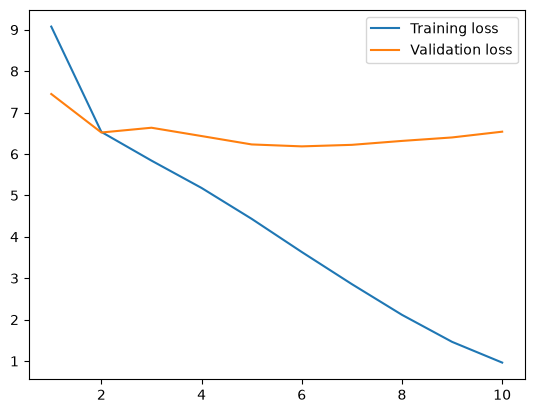

In [56]:
plt.plot(epochs, train_losses, label="Training loss")
plt.plot(epochs, val_losses, label="Validation loss")
plt.legend()
plt.show()

# Decoding strategies to control randomness

In [57]:
text = "Every effort moves you"

new_text = generate_text_test(25, text, model, device)
print(new_text)

Every effort moves you know his lean sunburnt cheeks furrowed by a smile that lifted the tips of a self-confident moust


## Temperature scaling

In [58]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8
}

inverse_vocab = {v: k for k, v in vocab.items()}

In [59]:
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

In [60]:
probs = torch.softmax(next_token_logits, dim=-1)
print(probs)

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])


In [61]:
next_token_id = torch.argmax(probs, dim=-1).item()
print(next_token_id)

3


In [146]:
#torch.manual_seed(123)
next_token_id = torch.multinomial(probs, num_samples=1).item()
print(next_token_id)
print(inverse_vocab[next_token_id])

3
forward


In [111]:
def softmax_with_temp(logits, temp):
    scaled_logits = logits / temp
    return torch.softmax(scaled_logits, dim=-1)

In [112]:
temps = [1, 0.1, 5]
for temp in temps:
    print(softmax_with_temp(next_token_logits, temp))

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])
tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])


## Top-k sampling

In [114]:
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

In [116]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print(top_logits)
print(top_pos)

tensor([6.7500, 6.2800, 4.5100])
tensor([3, 7, 0])


In [122]:
new_logits = torch.where(next_token_logits >= top_logits[-1], next_token_logits, torch.tensor(-torch.inf))
print(new_logits)
probs = torch.softmax(new_logits, dim=-1)
print(probs)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Modifying the text generation function

In [1]:
def generate_text_test(max_new_tokens, sample_text, model, device, temp=0.0, top_k=None, eos_id=None):
    model.to(device)
    tokenizer = tiktoken.get_encoding("gpt2")
    ids = tokenizer.encode(sample_text, allowed_special={"<|endoftext|>"})
    ids = torch.tensor(ids).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():

        for _ in range(max_new_tokens):
            logits = model(ids)
            logits = logits[:, -1].squeeze()

            if top_k:
                top_logits, top_pos = torch.topk(logits, top_k)
                logits = torch.where(logits >= top_logits[-1], logits, torch.tensor(-torch.inf))

            if temp > 0.0:
                probs = torch.softmax(logits / temp, dim=-1)
                id_next = torch.multinomial(probs, 1)

            else:
                id_next = torch.argmax(logits, dim=-1, keepdim=True)


            if id_next == eos_id:
                break
            ids = torch.cat((ids, id_next.unsqueeze(0)), dim=1)

    ids = ids.squeeze().tolist()
    text = tokenizer.decode(ids)

    return text

In [11]:
sample_text = "My dear"
temp = 1.4
top_k = 25
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(generate_text_test(25, sample_text, model, device, temp, top_k))

My dear--any more than if I'd never touched a little wild--I felt nervous and uncertain.

"Once, when


## Saving and loading a model

In [151]:
torch.save(model.state_dict(), "model.pth")

In [152]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

## Loading pretrained weights from OpenAI

In [163]:
import tensorflow
import tqdm
from gpt_download import download_and_load_gpt2

print(tensorflow.__version__)
print(tqdm.__version__)

2.21.0
4.69.0


In [164]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [169]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim" : 768,
                          "n_layers": 12,
                          "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim" : 1024,
                           "n_layers": 24,
                           "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim" : 1280,
                          "n_layers": 36,
                          "n_heads": 20},
    "gpt2-xl (1558)": {"emb_dim" : 1600,
                       "n_layers": 48,
                       "n_heads": 25},
}

model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [170]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [171]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device);

AttributeError: 'GPTModel' object has no attribute 'trf_blocks'